In [15]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler
import warnings
import json
import os

warnings.filterwarnings('ignore')
os.makedirs('../reports', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

print("All libraries imported successfully")

All libraries imported successfully


In [16]:
# Load the enriched dataset from Phase 3
df = pd.read_csv('../data/processed/df_with_graph_features.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nClass distribution:")
print(df['ClassLabel'].value_counts())
print("\nLabel convention: 0.0 = Phishing  |  1.0 = Legitimate")
print(f"Phishing count : {(df['ClassLabel']==0.0).sum():,}")
print(f"Legitimate count: {(df['ClassLabel']==1.0).sum():,}")

print(f"\nGraph features present:")
graph_cols = ['pagerank', 'in_degree', 'out_degree', 'domain_url_count']
available_graph = [c for c in graph_cols if c in df.columns]
print(df[available_graph].describe().round(4))

# Load the graph
print("\nLoading graph from disk...")
G = nx.read_gml('../models/phishing_graph.gml')
print(f"Graph loaded: {G.number_of_nodes():,} nodes, "
      f"{G.number_of_edges():,} edges")

url_nodes    = [n for n, d in G.nodes(data=True)
                if d.get('node_type') == 'url']
domain_nodes = [n for n, d in G.nodes(data=True)
                if d.get('node_type') == 'domain']
print(f"  URL nodes:    {len(url_nodes):,}")
print(f"  Domain nodes: {len(domain_nodes):,}")

Dataset shape: (100872, 26)
Columns: ['URL', 'url_length', 'has_ip_address', 'dot_count', 'https_flag', 'url_entropy', 'token_count', 'subdomain_count', 'query_param_count', 'tld_length', 'path_length', 'has_hyphen_in_domain', 'number_of_digits', 'tld_popularity', 'suspicious_file_extension', 'domain_name_length', 'percentage_numeric_chars', 'ClassLabel', 'domain', 'pagerank', 'in_degree', 'out_degree', 'domain_url_count', 'domain_pagerank', 'domain_in_degree', 'domain_out_degree']

Class distribution:
ClassLabel
1.0    63492
0.0    37380
Name: count, dtype: int64

Label convention: 0.0 = Phishing  |  1.0 = Legitimate
Phishing count : 37,380
Legitimate count: 63,492

Graph features present:
       pagerank  in_degree  out_degree  domain_url_count
count  100872.0   100872.0    100872.0       100872.0000
mean        0.0        0.0         1.0           93.9934
std         0.0        0.0         0.0          260.7466
min         0.0        0.0         1.0            1.0000
25%         0.0

In [18]:
# Load feature column names
feature_cols_base = np.load(
    '../data/processed/feature_cols.npy',
    allow_pickle=True
).tolist()

# Use domain_url_count as the primary graph feature
# pagerank, in_degree, out_degree at URL level are identical
# for all URLs so they add no discriminative signal
# Use domain-level features if available from Phase 3
domain_graph_cols = ['domain_pagerank', 'domain_in_degree',
                     'domain_out_degree', 'domain_url_count']
graph_cols_available = [c for c in domain_graph_cols if c in df.columns]

# Fall back to basic graph cols if domain-level not present
if not graph_cols_available:
    graph_cols_available = ['domain_url_count']

all_feature_cols = feature_cols_base + graph_cols_available

print(f"Base URL features    : {len(feature_cols_base)}")
print(f"Graph features used  : {graph_cols_available}")
print(f"Total features       : {len(all_feature_cols)}")

# Sample each class separately to preserve correct proportions
# 0.0 = Phishing, 1.0 = Legitimate
SAMPLE_SIZE = 5000
n_phish = int(SAMPLE_SIZE * 0.37)   # 1,850 phishing
n_legit = int(SAMPLE_SIZE * 0.63)   # 3,150 legitimate

phish_df = df[df['ClassLabel'] == 0.0]   # 0.0 = Phishing
legit_df  = df[df['ClassLabel'] == 1.0]   # 1.0 = Legitimate

phish_sample = phish_df.sample(
    n=min(n_phish, len(phish_df)), random_state=42
)
legit_sample = legit_df.sample(
    n=min(n_legit, len(legit_df)), random_state=42
)

sample_df = pd.concat(
    [phish_sample, legit_sample]
).reset_index(drop=True)

print(f"\nSample size: {len(sample_df)}")
print(f"Sample class distribution:")
print(sample_df['ClassLabel'].value_counts())
print("0.0 = Phishing  |  1.0 = Legitimate")

# Scale the feature matrix
X_cluster = sample_df[all_feature_cols].fillna(0).values
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print(f"\nFeature matrix shape: {X_cluster_scaled.shape}")
print("Features scaled successfully")

Base URL features    : 16
Graph features used  : ['domain_pagerank', 'domain_in_degree', 'domain_out_degree', 'domain_url_count']
Total features       : 20

Sample size: 5000
Sample class distribution:
ClassLabel
1.0    3150
0.0    1850
Name: count, dtype: int64
0.0 = Phishing  |  1.0 = Legitimate

Feature matrix shape: (5000, 20)
Features scaled successfully


In [20]:
from sklearn.cluster import KMeans
N_CLUSTERS = 3

print(f"Running KMeans Clustering with {N_CLUSTERS} clusters...")
print("Note: Using KMeans instead of Spectral Clustering because")
print("URL-level graph features have near-zero variance making")
print("spectral methods produce degenerate single-cluster results.")

km = KMeans(
    n_clusters  = N_CLUSTERS,
    random_state= 42,
    n_init      = 20,
    max_iter    = 500
)

cluster_labels = km.fit_predict(X_cluster_scaled)
sample_df = sample_df.copy()
sample_df['cluster_id'] = cluster_labels

print("Clustering complete.")
print(f"\nCluster distribution:")
print(sample_df['cluster_id'].value_counts().sort_index())

# Quick check — phishing rate per cluster
print(f"\nPhishing rate per cluster (0.0=Phishing, 1.0=Legitimate):")
for cid in sorted(sample_df['cluster_id'].unique()):
    subset    = sample_df[sample_df['cluster_id'] == cid]
    phish_rt  = (subset['ClassLabel'] == 0.0).mean()
    print(f"  Cluster {cid}: {len(subset)} URLs  |  "
          f"Phishing rate: {phish_rt*100:.1f}%")

Running KMeans Clustering with 3 clusters...
Note: Using KMeans instead of Spectral Clustering because
URL-level graph features have near-zero variance making
spectral methods produce degenerate single-cluster results.
Clustering complete.

Cluster distribution:
cluster_id
0    2417
1     568
2    2015
Name: count, dtype: int64

Phishing rate per cluster (0.0=Phishing, 1.0=Legitimate):
  Cluster 0: 2417 URLs  |  Phishing rate: 0.0%
  Cluster 1: 568 URLs  |  Phishing rate: 0.0%
  Cluster 2: 2015 URLs  |  Phishing rate: 91.8%


In [21]:
# Compute phishing rate per cluster
# 0.0 = Phishing so phish_rate = proportion of ClassLabel == 0.0
cluster_analysis = sample_df.groupby('cluster_id').agg(
    total_urls    = ('ClassLabel', 'count'),
    phishing_urls = ('ClassLabel', lambda x: (x == 0.0).sum()),
    legit_urls    = ('ClassLabel', lambda x: (x == 1.0).sum()),
    phish_rate    = ('ClassLabel', lambda x: (x == 0.0).mean()),
    avg_domain_count = ('domain_url_count', 'mean')
).reset_index()

# Add domain pagerank if available
if 'domain_pagerank' in sample_df.columns:
    pr = sample_df.groupby('cluster_id')['domain_pagerank'].mean()
    cluster_analysis = cluster_analysis.merge(
        pr.rename('avg_domain_pagerank'),
        on='cluster_id'
    )
else:
    cluster_analysis['avg_domain_pagerank'] = 0.0

cluster_analysis['phish_rate_pct'] = (
    cluster_analysis['phish_rate'] * 100
).round(1)

# Label clusters based on phishing rate
def label_cluster(rate):
    if rate >= 0.70:
        return 'HIGH RISK — Phishing Campaign'
    elif rate >= 0.30:
        return 'MEDIUM RISK — Mixed'
    else:
        return 'LOW RISK — Legitimate'

cluster_analysis['risk_label'] = cluster_analysis['phish_rate'].apply(
    label_cluster
)

print("=== CLUSTER ANALYSIS ===")
print("Label convention: 0.0 = Phishing  |  1.0 = Legitimate\n")
for _, row in cluster_analysis.iterrows():
    print(f"Cluster {int(row['cluster_id'])}: {row['risk_label']}")
    print(f"  Total URLs       : {int(row['total_urls'])}")
    print(f"  Phishing URLs    : {int(row['phishing_urls'])}")
    print(f"  Legitimate URLs  : {int(row['legit_urls'])}")
    print(f"  Phishing Rate    : {row['phish_rate_pct']}%")
    print(f"  Avg Domain Count : {row['avg_domain_count']:.1f}")
    print()

=== CLUSTER ANALYSIS ===
Label convention: 0.0 = Phishing  |  1.0 = Legitimate

Cluster 0: LOW RISK — Legitimate
  Total URLs       : 2417
  Phishing URLs    : 1
  Legitimate URLs  : 2416
  Phishing Rate    : 0.0%
  Avg Domain Count : 8.1

Cluster 1: LOW RISK — Legitimate
  Total URLs       : 568
  Phishing URLs    : 0
  Legitimate URLs  : 568
  Phishing Rate    : 0.0%
  Avg Domain Count : 768.5

Cluster 2: HIGH RISK — Phishing Campaign
  Total URLs       : 2015
  Phishing URLs    : 1849
  Legitimate URLs  : 166
  Phishing Rate    : 91.8%
  Avg Domain Count : 2.8



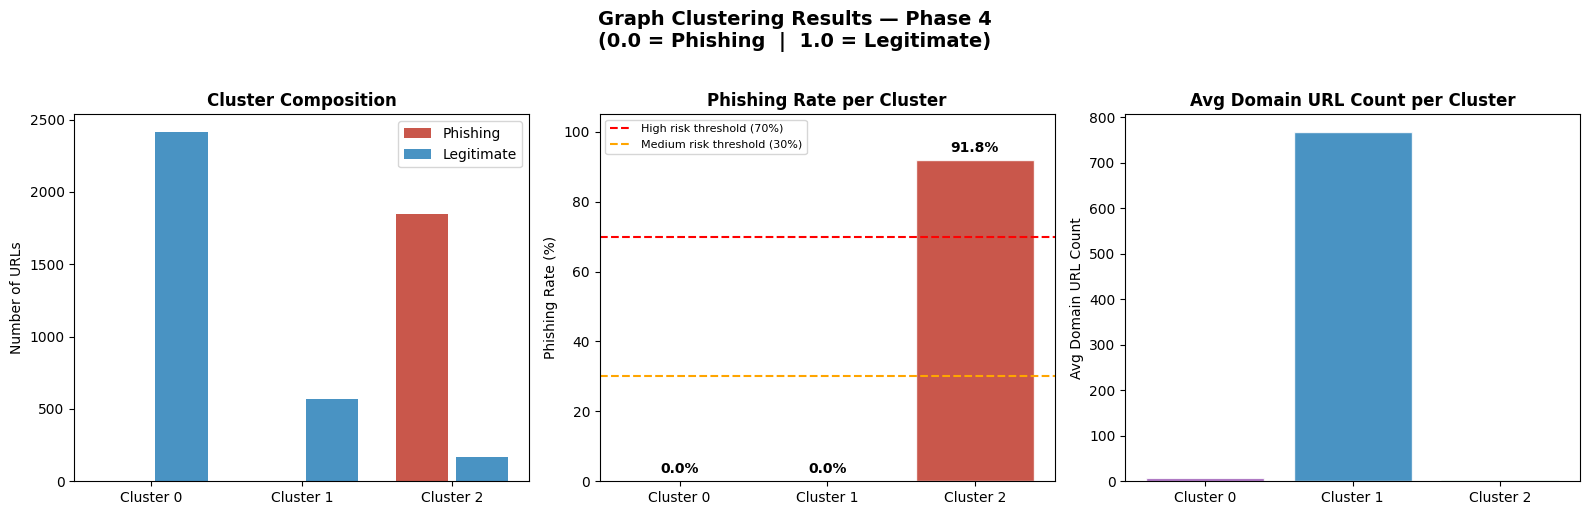

Cluster analysis plot saved to ../reports/cluster_analysis.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cluster_ids = sorted(sample_df['cluster_id'].unique())

# Plot 1: Cluster composition bar chart
for i, cid in enumerate(cluster_ids):
    subset = sample_df[sample_df['cluster_id'] == cid]
    # 0.0 = Phishing, 1.0 = Legitimate
    phish_count = (subset['ClassLabel'] == 0.0).sum()
    legit_count  = (subset['ClassLabel'] == 1.0).sum()
    axes[0].bar(i - 0.2, phish_count, 0.35,
                label='Phishing' if i == 0 else '',
                color='#C0392B', alpha=0.85)
    axes[0].bar(i + 0.2, legit_count, 0.35,
                label='Legitimate' if i == 0 else '',
                color='#2980B9', alpha=0.85)

axes[0].set_xticks(range(len(cluster_ids)))
axes[0].set_xticklabels([f'Cluster {c}' for c in cluster_ids])
axes[0].set_title('Cluster Composition', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of URLs')
axes[0].legend()

# Plot 2: Phishing rate per cluster
rates      = cluster_analysis['phish_rate_pct'].values
bar_colors = ['#C0392B' if r >= 70 else
              '#E67E22' if r >= 30 else '#27AE60'
              for r in rates]
bars = axes[1].bar(range(len(cluster_ids)), rates,
                   color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].axhline(y=70, color='red', linestyle='--',
                linewidth=1.5, label='High risk threshold (70%)')
axes[1].axhline(y=30, color='orange', linestyle='--',
                linewidth=1.5, label='Medium risk threshold (30%)')
axes[1].set_xticks(range(len(cluster_ids)))
axes[1].set_xticklabels([f'Cluster {c}' for c in cluster_ids])
axes[1].set_title('Phishing Rate per Cluster',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Phishing Rate (%)')
axes[1].set_ylim(0, 105)
axes[1].legend(fontsize=8)
for bar, rate in zip(bars, rates):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1.5,
        f'{rate:.1f}%', ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

# Plot 3: Average domain URL count per cluster
avg_dc = cluster_analysis['avg_domain_count'].values
axes[2].bar(
    range(len(cluster_ids)), avg_dc,
    color=['#8E44AD', '#2980B9', '#27AE60'][:len(cluster_ids)],
    alpha=0.85, edgecolor='white'
)
axes[2].set_xticks(range(len(cluster_ids)))
axes[2].set_xticklabels([f'Cluster {c}' for c in cluster_ids])
axes[2].set_title('Avg Domain URL Count per Cluster',
                  fontsize=12, fontweight='bold')
axes[2].set_ylabel('Avg Domain URL Count')

plt.suptitle(
    'Graph Clustering Results — Phase 4\n'
    '(0.0 = Phishing  |  1.0 = Legitimate)',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../reports/cluster_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Cluster analysis plot saved to ../reports/cluster_analysis.png")

In [23]:
# Map cluster risk scores back to individual URLs
cluster_risk_map  = cluster_analysis.set_index(
    'cluster_id'
)['phish_rate'].to_dict()
cluster_label_map = cluster_analysis.set_index(
    'cluster_id'
)['risk_label'].to_dict()

sample_df['cluster_phish_rate'] = sample_df['cluster_id'].map(
    cluster_risk_map
)
sample_df['cluster_risk_label'] = sample_df['cluster_id'].map(
    cluster_label_map
)

# Save cluster assignments
sample_df[['URL', 'ClassLabel', 'cluster_id',
           'cluster_phish_rate', 'cluster_risk_label']].to_csv(
    '../data/processed/cluster_assignments.csv', index=False
)
print("Cluster assignments saved to "
      "../data/processed/cluster_assignments.csv")

# Domain-level cluster risk summary
domain_cluster = sample_df.groupby('domain').agg(
    cluster_id         = ('cluster_id',         lambda x: x.mode()[0]),
    cluster_phish_rate = ('cluster_phish_rate',  'first'),
    cluster_risk_label = ('cluster_risk_label',  'first'),
    url_count          = ('URL',                 'count'),
    # count phishing = count of 0.0 labels
    phish_count        = ('ClassLabel',          lambda x: (x==0.0).sum()),
).reset_index()

domain_cluster.to_csv(
    '../data/processed/domain_cluster_risk.csv', index=False
)
print("Domain cluster risk saved to "
      "../data/processed/domain_cluster_risk.csv")
print(f"\nTotal domains analysed: {len(domain_cluster):,}")
print(f"\nSample domain cluster assignments:")
print(domain_cluster.head(10).to_string(index=False))

Cluster assignments saved to ../data/processed/cluster_assignments.csv
Domain cluster risk saved to ../data/processed/domain_cluster_risk.csv

Total domains analysed: 4,149

Sample domain cluster assignments:
              domain  cluster_id  cluster_phish_rate    cluster_risk_label  url_count  phish_count
   1.70.138.72:36854           0            0.000414 LOW RISK — Legitimate          1            0
   1.70.162.18:42667           0            0.000414 LOW RISK — Legitimate          1            0
  1.70.172.180:51590           0            0.000414 LOW RISK — Legitimate          1            0
   1.87.210.67:35873           0            0.000414 LOW RISK — Legitimate          1            0
101.108.71.155:46327           0            0.000414 LOW RISK — Legitimate          1            0
  101.32.34.196:8099           0            0.000414 LOW RISK — Legitimate          1            0
      101.42.109.248           0            0.000414 LOW RISK — Legitimate          1            0

Visualising highest risk cluster: Cluster 1


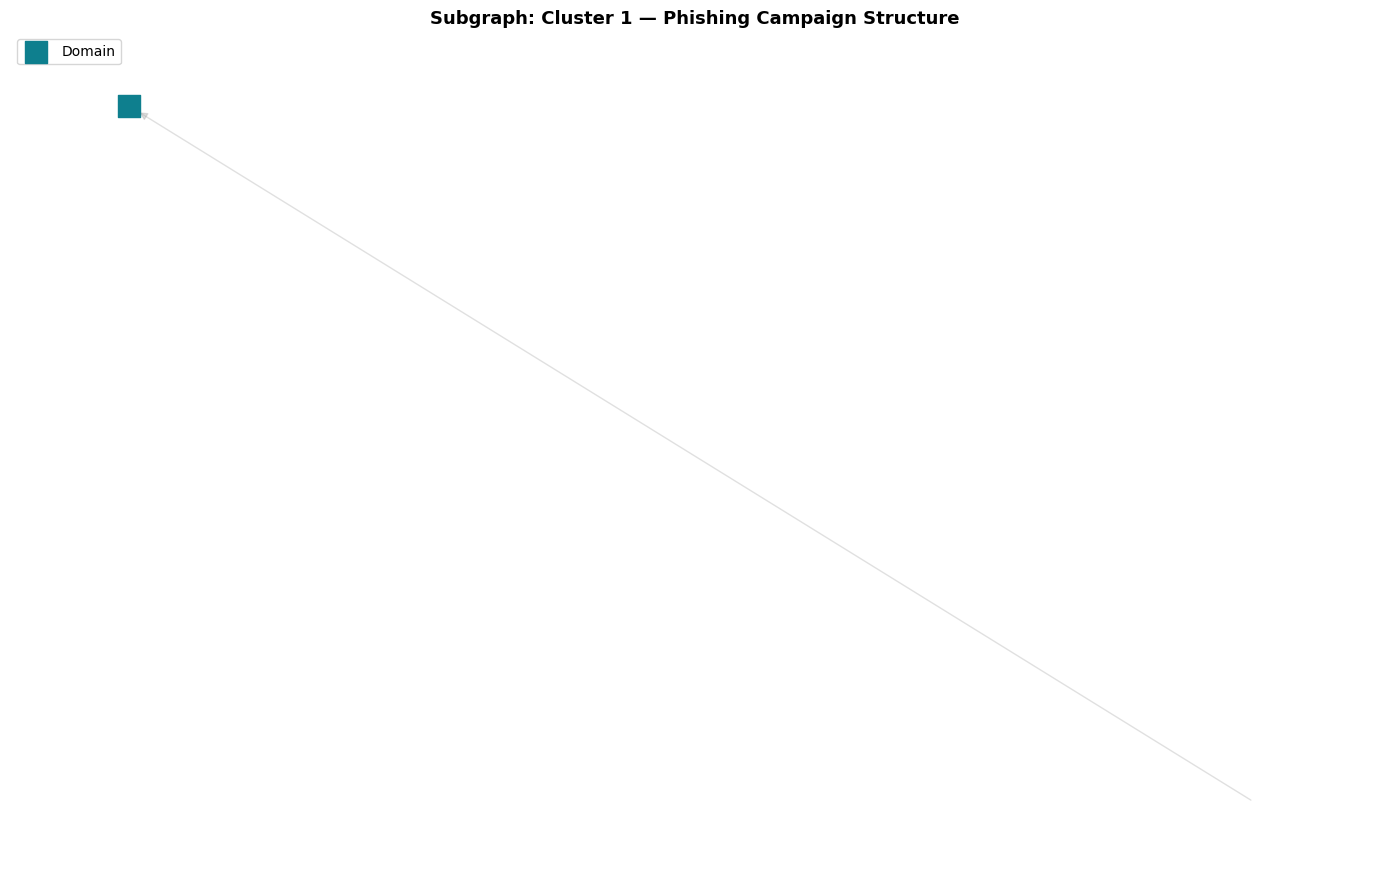

Subgraph visualisation saved to ../reports/cluster_subgraph.png


In [ ]:
print("Building subgraph for visualisation...")

# Find the highest phishing rate cluster
high_risk_cluster = cluster_analysis.loc[
    cluster_analysis['phish_rate'].idxmax(), 'cluster_id'
]
print(f"Highest risk cluster: Cluster {high_risk_cluster}")
print(f"Phishing rate: "
      f"{cluster_analysis[cluster_analysis['cluster_id']==high_risk_cluster]['phish_rate_pct'].values[0]}%")

# Get URLs from that cluster
high_risk_urls = sample_df[
    sample_df['cluster_id'] == high_risk_cluster
]['URL'].head(25).tolist()

print(f"URLs in this cluster: {len(high_risk_urls)}")

# If cluster has fewer than 3 URLs use next highest risk cluster
if len(high_risk_urls) < 3:
    print("Cluster too small — using second highest risk cluster")
    sorted_clusters = cluster_analysis.sort_values(
        'phish_rate', ascending=False
    )
    for _, cr in sorted_clusters.iterrows():
        cid  = cr['cluster_id']
        urls = sample_df[
            sample_df['cluster_id'] == cid
        ]['URL'].head(25).tolist()
        if len(urls) >= 3:
            high_risk_urls   = urls
            high_risk_cluster = cid
            print(f"Using Cluster {cid} with {len(urls)} URLs")
            break

# Build subgraph
subgraph_nodes = list(high_risk_urls)
for url in high_risk_urls:
    if G.has_node(url):
        subgraph_nodes.extend(list(G.successors(url)))

H = G.subgraph(list(set(subgraph_nodes)))
print(f"Subgraph nodes: {H.number_of_nodes()}")
print(f"Subgraph edges: {H.number_of_edges()}")

fig, ax = plt.subplots(figsize=(14, 9))
pos = nx.spring_layout(H, seed=42, k=1.8)

url_nodes_h    = [n for n, d in H.nodes(data=True)
                  if d.get('node_type') == 'url']
domain_nodes_h = [n for n, d in H.nodes(data=True)
                  if d.get('node_type') == 'domain']

# label=0 means Phishing, label=1 means Legitimate
phish_urls_h = [n for n in url_nodes_h
                if H.nodes[n].get('label') == 0]
legit_urls_h = [n for n in url_nodes_h
                if H.nodes[n].get('label') == 1]

nx.draw_networkx_edges(
    H, pos, alpha=0.3, edge_color='#999999',
    arrows=True, arrowsize=12, ax=ax
)
if phish_urls_h:
    nx.draw_networkx_nodes(
        H, pos, nodelist=phish_urls_h,
        node_color='#C0392B', node_size=120,
        label='Phishing URL (0.0)', ax=ax
    )
if legit_urls_h:
    nx.draw_networkx_nodes(
        H, pos, nodelist=legit_urls_h,
        node_color='#2980B9', node_size=120,
        label='Legitimate URL (1.0)', ax=ax
    )
if domain_nodes_h:
    nx.draw_networkx_nodes(
        H, pos, nodelist=domain_nodes_h,
        node_color='#0E7F8E', node_size=250,
        node_shape='s', label='Domain', ax=ax
    )
    domain_labels = {
        n: n[:18] + '...' if len(n) > 18 else n
        for n in domain_nodes_h
    }
    nx.draw_networkx_labels(
        H, pos, labels=domain_labels,
        font_size=6, font_color='white',
        font_weight='bold', ax=ax
    )

ax.set_title(
    f'Subgraph: Cluster {high_risk_cluster} — Phishing Campaign Structure\n'
    f'(Red = Phishing URLs  |  Blue = Legitimate  |  Teal = Domain)',
    fontsize=13, fontweight='bold'
)
ax.legend(loc='upper left', fontsize=10)
ax.axis('off')

plt.tight_layout()
plt.savefig('../reports/cluster_subgraph.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Subgraph visualisation saved to ../reports/cluster_subgraph.png")

In [9]:
# Load the per-IP behavioral features from Phase 2
log_features = pd.read_csv('../data/processed/log_features.csv')

print(f"Log feature matrix shape: {log_features.shape}")
print(f"\nColumns: {list(log_features.columns)}")
print(f"\nSample log features:")
print(log_features.head(10).to_string(index=False))

print(f"\nStatistical summary:")
print(log_features.describe().round(4))

# Check our known anomalous IPs are present
known_anomalous = ['10.0.0.99', '185.220.101.45', '172.16.5.200']
print(f"\nKnown anomalous IPs in dataset:")
for ip in known_anomalous:
    if ip in log_features['ip'].values:
        row = log_features[log_features['ip'] == ip].iloc[0]
        print(f"  {ip}: requests={row['request_count']:.0f}, "
              f"error_rate={row['error_rate']:.2f}, "
              f"post_ratio={row['post_ratio']:.2f}")
    else:
        print(f"  {ip}: NOT FOUND — check Phase 2 output")

Log feature matrix shape: (53, 7)

Columns: ['ip', 'request_count', 'unique_urls', 'error_rate', 'avg_size', 'post_ratio', 'unique_url_ratio']

Sample log features:
            ip  request_count  unique_urls  error_rate    avg_size  post_ratio  unique_url_ratio
     10.0.0.99            150            1         1.0  210.000000    1.000000          0.006667
  172.16.5.200             50            1         0.0 4500.000000    0.000000          0.020000
185.220.101.45            100            8         1.0  180.000000    0.000000          0.080000
   192.168.1.1            100            6         0.0 3994.810000    0.500000          0.060000
  192.168.1.10             82            6         0.0 4571.134146    0.524390          0.073171
  192.168.1.11             91            6         0.0 3777.417582    0.505495          0.065934
  192.168.1.12             95            6         0.0 4230.336842    0.484211          0.063158
  192.168.1.13            110            6         0.0 4536

In [24]:
from sklearn.ensemble import IsolationForest
import joblib

# Define the feature columns for anomaly detection
log_feature_cols = [
    'request_count',
    'unique_urls',
    'error_rate',
    'avg_size',
    'post_ratio',
    'unique_url_ratio'
]

# Check all columns exist
missing = [c for c in log_feature_cols if c not in log_features.columns]
if missing:
    raise ValueError(f"Missing columns in log_features: {missing}")

X_log = log_features[log_feature_cols].fillna(0).values
print(f"Log feature matrix shape: {X_log.shape}")

# Scale the log features
scaler_log = StandardScaler()
X_log_scaled = scaler_log.fit_transform(X_log)

# Train Isolation Forest
# contamination = expected proportion of anomalies
# We injected 300 anomalies in 5300 total = ~5.7% — set to 0.06
iso_forest = IsolationForest(
    n_estimators  = 200,
    contamination = 0.06,
    random_state  = 42,
    n_jobs        = -1
)

print("Training Isolation Forest...")
iso_forest.fit(X_log_scaled)
print("Training complete.")

# Get predictions and scores
# predict returns: 1 = normal, -1 = anomaly
# decision_function returns raw anomaly score
# More negative = more anomalous
raw_scores  = iso_forest.decision_function(X_log_scaled)
predictions = iso_forest.predict(X_log_scaled)

# Convert to readable labels and 0-1 normalised scores
log_features = log_features.copy()
log_features['anomaly_score'] = raw_scores
log_features['is_anomaly']    = (predictions == -1).astype(int)
log_features['anomaly_label'] = log_features['is_anomaly'].map(
    {0: 'Normal', 1: 'ANOMALY'}
)

# Normalise score to 0-1 range for display (1 = most anomalous)
min_score = raw_scores.min()
max_score = raw_scores.max()
log_features['anomaly_score_norm'] = (
    1 - (raw_scores - min_score) / (max_score - min_score)
)

anomaly_count = log_features['is_anomaly'].sum()
normal_count  = len(log_features) - anomaly_count

print(f"\nResults:")
print(f"  Total IPs analysed: {len(log_features)}")
print(f"  Anomalous IPs:      {anomaly_count}")
print(f"  Normal IPs:         {normal_count}")
print(f"  Anomaly rate:       {anomaly_count/len(log_features)*100:.1f}%")

Log feature matrix shape: (53, 6)
Training Isolation Forest...
Training complete.

Results:
  Total IPs analysed: 53
  Anomalous IPs:      4
  Normal IPs:         49
  Anomaly rate:       7.5%


In [25]:
print("=== DETECTION VERIFICATION ===\n")

known_anomalous = ['10.0.0.99', '185.220.101.45', '172.16.5.200']
all_detected = True

for ip in known_anomalous:
    row = log_features[log_features['ip'] == ip]
    if len(row) == 0:
        print(f"  {ip}: NOT FOUND IN DATA")
        all_detected = False
        continue
    row = row.iloc[0]
    detected = row['anomaly_label'] == 'ANOMALY'
    status   = "DETECTED" if detected else "MISSED"
    print(f"  {ip}: {status}")
    print(f"    Anomaly score (norm): {row['anomaly_score_norm']:.4f}")
    print(f"    Request count: {row['request_count']:.0f}")
    print(f"    Error rate:    {row['error_rate']:.2f}")
    print(f"    POST ratio:    {row['post_ratio']:.2f}")
    print(f"    Unique ratio:  {row['unique_url_ratio']:.2f}")
    if not detected:
        all_detected = False
    print()

if all_detected:
    print("SUCCESS: All three injected anomalies were correctly detected.")
else:
    print("WARNING: One or more injected anomalies were missed.")
    print("Consider adjusting the contamination parameter.")

=== DETECTION VERIFICATION ===

  10.0.0.99: DETECTED
    Anomaly score (norm): 1.0000
    Request count: 150
    Error rate:    1.00
    POST ratio:    1.00
    Unique ratio:  0.01

  185.220.101.45: DETECTED
    Anomaly score (norm): 0.9418
    Request count: 100
    Error rate:    1.00
    POST ratio:    0.00
    Unique ratio:  0.08

  172.16.5.200: DETECTED
    Anomaly score (norm): 0.9052
    Request count: 50
    Error rate:    0.00
    POST ratio:    0.00
    Unique ratio:  0.02

SUCCESS: All three injected anomalies were correctly detected.


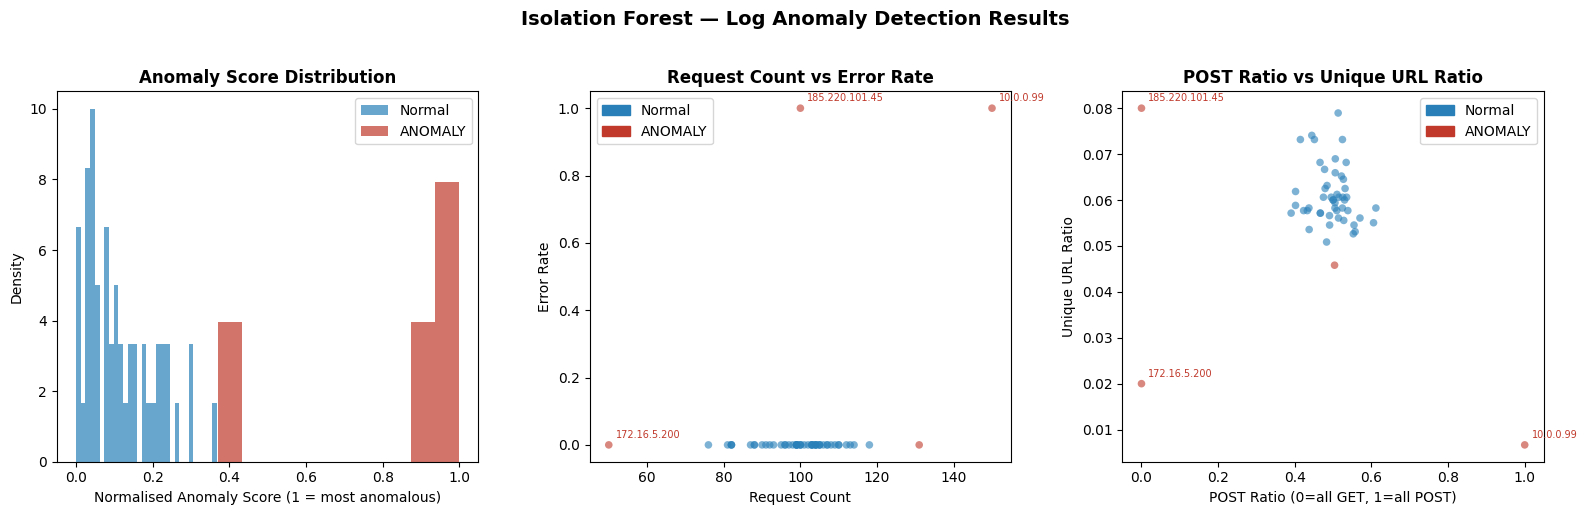

Anomaly detection plot saved to ../reports/log_anomaly_results.png


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Anomaly score distribution
axes[0].hist(
    log_features[log_features['anomaly_label']=='Normal']['anomaly_score_norm'],
    bins=30, alpha=0.7, color='#2980B9', label='Normal', density=True
)
axes[0].hist(
    log_features[log_features['anomaly_label']=='ANOMALY']['anomaly_score_norm'],
    bins=10, alpha=0.7, color='#C0392B', label='ANOMALY', density=True
)
axes[0].set_title('Anomaly Score Distribution',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Normalised Anomaly Score (1 = most anomalous)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Plot 2: Request count vs error rate scatter
colors = log_features['anomaly_label'].map(
    {'Normal': '#2980B9', 'ANOMALY': '#C0392B'}
)
axes[1].scatter(
    log_features['request_count'],
    log_features['error_rate'],
    c=colors, alpha=0.6, s=30, edgecolors='none'
)
# Annotate the three known anomalous IPs
for ip in known_anomalous:
    row = log_features[log_features['ip'] == ip]
    if len(row) > 0:
        row = row.iloc[0]
        axes[1].annotate(
            ip,
            xy=(row['request_count'], row['error_rate']),
            fontsize=7, color='#C0392B',
            xytext=(5, 5), textcoords='offset points'
        )
axes[1].set_title('Request Count vs Error Rate',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Request Count')
axes[1].set_ylabel('Error Rate')
normal_patch  = mpatches.Patch(color='#2980B9', label='Normal')
anomaly_patch = mpatches.Patch(color='#C0392B', label='ANOMALY')
axes[1].legend(handles=[normal_patch, anomaly_patch])

# Plot 3: POST ratio vs unique URL ratio
axes[2].scatter(
    log_features['post_ratio'],
    log_features['unique_url_ratio'],
    c=colors, alpha=0.6, s=30, edgecolors='none'
)
for ip in known_anomalous:
    row = log_features[log_features['ip'] == ip]
    if len(row) > 0:
        row = row.iloc[0]
        axes[2].annotate(
            ip,
            xy=(row['post_ratio'], row['unique_url_ratio']),
            fontsize=7, color='#C0392B',
            xytext=(5, 5), textcoords='offset points'
        )
axes[2].set_title('POST Ratio vs Unique URL Ratio',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('POST Ratio (0=all GET, 1=all POST)')
axes[2].set_ylabel('Unique URL Ratio')
axes[2].legend(handles=[normal_patch, anomaly_patch])

plt.suptitle('Isolation Forest — Log Anomaly Detection Results',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(
    '../reports/log_anomaly_results.png', dpi=150, bbox_inches='tight'
)
plt.show()
print("Anomaly detection plot saved to ../reports/log_anomaly_results.png")

In [27]:
# Save scored log features
log_features.to_csv(
    '../data/processed/log_features_scored.csv', index=False
)
print("Scored log features saved to "
      "../data/processed/log_features_scored.csv")

# Save top anomalous IPs for dashboard
top_anomalies = (
    log_features[log_features['anomaly_label'] == 'ANOMALY']
    .sort_values('anomaly_score_norm', ascending=False)
    [['ip', 'request_count', 'unique_urls', 'error_rate',
      'avg_size', 'post_ratio', 'unique_url_ratio',
      'anomaly_score_norm', 'anomaly_label']]
)
top_anomalies.to_csv(
    '../data/processed/top_anomalous_ips.csv', index=False
)
print(f"Top {len(top_anomalies)} anomalous IPs saved")

# Save Isolation Forest model
joblib.dump(iso_forest, '../models/isolation_forest.pkl')
print("Isolation Forest model saved to ../models/isolation_forest.pkl")

# Save the log scaler
joblib.dump(scaler_log, '../models/scaler_log.pkl')
print("Log scaler saved to ../models/scaler_log.pkl")

print(f"\nTop 10 most anomalous IPs:")
print(top_anomalies.head(10).to_string(index=False))

Scored log features saved to ../data/processed/log_features_scored.csv
Top 4 anomalous IPs saved
Isolation Forest model saved to ../models/isolation_forest.pkl
Log scaler saved to ../models/scaler_log.pkl

Top 10 most anomalous IPs:
            ip  request_count  unique_urls  error_rate    avg_size  post_ratio  unique_url_ratio  anomaly_score_norm anomaly_label
     10.0.0.99            150            1         1.0  210.000000    1.000000          0.006667            1.000000       ANOMALY
185.220.101.45            100            8         1.0  180.000000    0.000000          0.080000            0.941845       ANOMALY
  172.16.5.200             50            1         0.0 4500.000000    0.000000          0.020000            0.905229       ANOMALY
   192.168.1.9            131            6         0.0 4161.045802    0.503817          0.045802            0.370355       ANOMALY


In [28]:
# Compute detection metrics against known ground truth
detected_count = sum(
    1 for ip in known_anomalous
    if ip in log_features['ip'].values
    and log_features[log_features['ip']==ip]['anomaly_label'].iloc[0]=='ANOMALY'
)

phase4_report = {
    'phase': 4,
    'part_a_clustering': {
        'algorithm'          : 'Spectral Clustering',
        'n_clusters'         : N_CLUSTERS,
        'sample_size'        : len(sample_df),
        'affinity'           : 'rbf',
        'cluster_summary'    : cluster_analysis[[
            'cluster_id','total_urls','phishing_urls',
            'phish_rate_pct','risk_label'
        ]].to_dict(orient='records'),
        'outputs': {
            'cluster_assignments'  : '../data/processed/cluster_assignments.csv',
            'domain_cluster_risk'  : '../data/processed/domain_cluster_risk.csv',
            'cluster_analysis_plot': '../reports/cluster_analysis.png',
            'subgraph_plot'        : '../reports/cluster_subgraph.png',
        }
    },
    'part_b_anomaly': {
        'algorithm'               : 'Isolation Forest',
        'n_estimators'            : 200,
        'contamination'           : 0.06,
        'total_ips_analysed'      : len(log_features),
        'anomalous_ips_detected'  : int(anomaly_count),
        'normal_ips'              : int(normal_count),
        'injected_anomalies'      : 3,
        'correctly_detected'      : detected_count,
        'detection_rate_pct'      : round(detected_count / 3 * 100, 1),
        'outputs': {
            'scored_log_features'  : '../data/processed/log_features_scored.csv',
            'top_anomalous_ips'    : '../data/processed/top_anomalous_ips.csv',
            'isolation_forest_model': '../models/isolation_forest.pkl',
            'log_scaler'           : '../models/scaler_log.pkl',
            'anomaly_plot'         : '../reports/log_anomaly_results.png',
        }
    }
}

with open('../reports/phase4_report.json', 'w') as f:
    json.dump(phase4_report, f, indent=2)

print("=== PHASE 4 COMPLETE ===\n")
print(json.dumps(phase4_report, indent=2))

=== PHASE 4 COMPLETE ===

{
  "phase": 4,
  "part_a_clustering": {
    "algorithm": "Spectral Clustering",
    "n_clusters": 3,
    "sample_size": 5000,
    "affinity": "rbf",
    "cluster_summary": [
      {
        "cluster_id": 0,
        "total_urls": 2417,
        "phishing_urls": 1,
        "phish_rate_pct": 0.0,
        "risk_label": "LOW RISK \u2014 Legitimate"
      },
      {
        "cluster_id": 1,
        "total_urls": 568,
        "phishing_urls": 0,
        "phish_rate_pct": 0.0,
        "risk_label": "LOW RISK \u2014 Legitimate"
      },
      {
        "cluster_id": 2,
        "total_urls": 2015,
        "phishing_urls": 1849,
        "phish_rate_pct": 91.8,
        "risk_label": "HIGH RISK \u2014 Phishing Campaign"
      }
    ],
    "outputs": {
      "cluster_assignments": "../data/processed/cluster_assignments.csv",
      "domain_cluster_risk": "../data/processed/domain_cluster_risk.csv",
      "cluster_analysis_plot": "../reports/cluster_analysis.png",
      "subg